Livelli disponibili (hPa): [  50  100  150  200  250  300  400  500  600  700  850  925 1000]

Punto griglia scelto: lat=47.500, lon=8.500
Data effettiva: 2023-01-10T18:00:00.000000000

Profilo T (°C):
     50 hPa :  -66.85 °C
    100 hPa :  -61.08 °C
    150 hPa :  -69.05 °C
    200 hPa :  -67.27 °C
    250 hPa :  -56.54 °C
    300 hPa :  -47.01 °C
    400 hPa :  -30.46 °C
    500 hPa :  -19.89 °C
    600 hPa :  -12.71 °C
    700 hPa :   -6.54 °C
    850 hPa :   -0.87 °C
    925 hPa :   +2.65 °C
   1000 hPa :   +7.02 °C


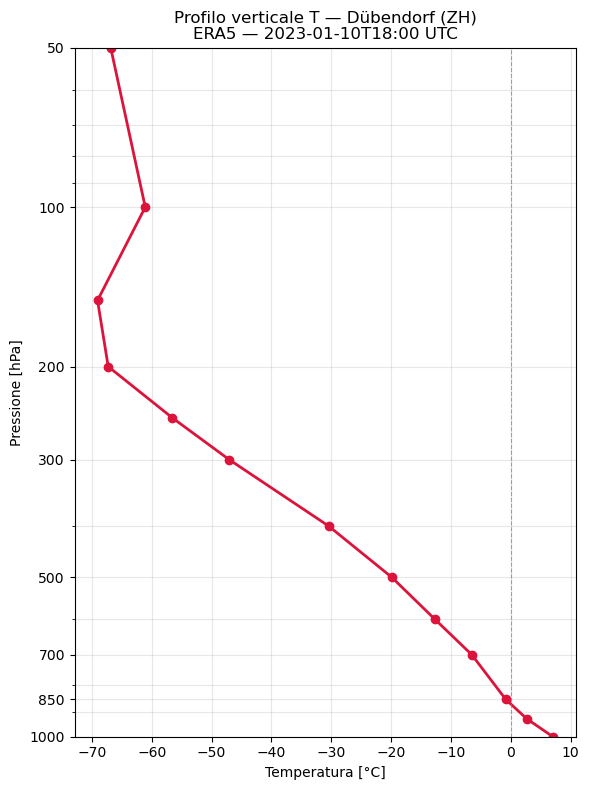

In [ ]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. Carica ERA5 da weatherbench2 con 13 livelli di pressione
# ============================================================
# Questo dataset ha 13 livelli: 50, 100, 150, 200, 250, 300, 400,
# 500, 600, 700, 850, 925, 1000 hPa  —  risoluzione 6h, 0.25°
era5_path = 'gs://weatherbench2/datasets/era5/1959-2023_01_10-wb13-6h-1440x721_with_derived_variables.zarr'

xera5 = xr.open_zarr(era5_path, consolidated=True, decode_timedelta=True)
print("Livelli disponibili (hPa):", xera5.level.values)

# ============================================================
# 2. Coordinate di Dübendorf (Zurigo)
# ============================================================
lat_dub = 47.40
lon_dub = 8.62   # ERA5 su wb2 usa longitudini 0–360, 8.62°E va bene così

# ============================================================
# 3. Data/ora da visualizzare
# ============================================================
# ERA5 wb2 è a step di 6h (00, 06, 12, 18 UTC)
date_sel = '2026-02-05T12:00:00'

# ============================================================
# 4. Estrai il profilo verticale di temperatura
# ============================================================
temp_profile = xera5['temperature'].sel(
    latitude=lat_dub,
    longitude=lon_dub,
    time=date_sel,
    method='nearest'
).load()   # carica in memoria (piccolo: solo 13 valori)

# Converti da Kelvin a Celsius
temp_profile_C = temp_profile - 273.15

# Info sul punto effettivamente selezionato (punto griglia più vicino)
print(f"\nPunto griglia scelto: "
      f"lat={float(temp_profile.latitude):.3f}, "
      f"lon={float(temp_profile.longitude):.3f}")
print(f"Data effettiva: {temp_profile.time.values}")
print("\nProfilo T (°C):")
for lev, T in zip(temp_profile_C.level.values, temp_profile_C.values):
    print(f"  {lev:>5} hPa :  {T:+6.2f} °C")

# ============================================================
# 5. Plot del profilo verticale
# ============================================================
fig, ax = plt.subplots(figsize=(6, 8))

ax.plot(temp_profile_C.values, temp_profile_C.level.values,
        marker='o', linewidth=2, color='crimson')

# Linea 0 °C di riferimento
ax.axvline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)

ax.invert_yaxis()              # pressione bassa in alto (come un vero sondaggio)
ax.set_yscale('log')           # scala log (standard per profili atmosferici)
ax.set_yticks([1000, 850, 700, 500, 300, 200, 100, 50])
ax.set_yticklabels([1000, 850, 700, 500, 300, 200, 100, 50])
ax.set_ylim(1000, 50)

ax.set_xlabel('Temperatura [°C]')
ax.set_ylabel('Pressione [hPa]')
ax.set_title(f'Profilo verticale T — Dübendorf (ZH)\n'
             f'ERA5 — {str(temp_profile.time.values)[:16]} UTC')
ax.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()

Punto griglia: lat=47.500, lon=8.500
Data: 2023-01-10T18:00:00.000000000

 p [hPa]   u [m/s]   v [m/s]  |V| [m/s]   dir [°]
--------------------------------------------------
      50    +24.85     -9.78      26.70       291
     100    +13.53    -14.18      19.60       316
     150    +19.20    -21.44      28.78       318
     200    +16.39    -37.32      40.76       336
     250    +17.70    -34.14      38.45       333
     300    +17.48    -28.12      33.11       328
     400     +9.39    -23.82      25.60       338
     500     +7.84    -18.18      19.80       337
     600    +12.80    -13.86      18.87       317
     700    +12.63     -7.24      14.56       300
     850    +11.38     +5.19      12.51       245
     925     +3.11     +4.19       5.21       217
    1000     +0.56     +0.76       0.95       216


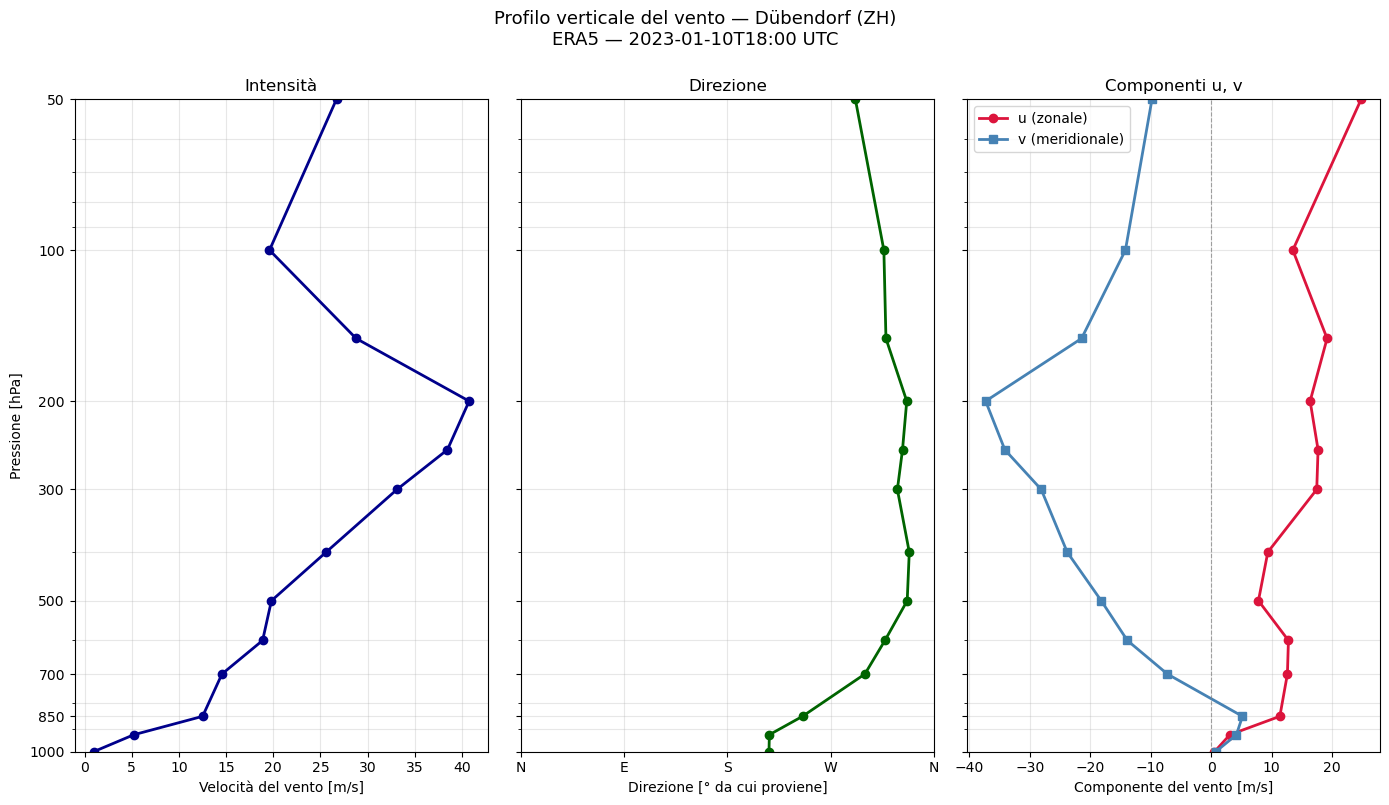

In [ ]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. Carica ERA5 da weatherbench2 con 13 livelli di pressione
# ============================================================
era5_path = 'gs://weatherbench2/datasets/era5/1959-2023_01_10-wb13-6h-1440x721_with_derived_variables.zarr'
xera5 = xr.open_zarr(era5_path, consolidated=True, decode_timedelta=True)

# ============================================================
# 2. Coordinate di Dübendorf (Zurigo) e data
# ============================================================
lat_dub = 47.40
lon_dub = 8.62
date_sel = '2026-02-05T12:00:00'

# ============================================================
# 3. Estrai componenti u, v e wind_speed
# ============================================================
sel_kwargs = dict(latitude=lat_dub, longitude=lon_dub,
                  time=date_sel, method='nearest')

u = xera5['u_component_of_wind'].sel(**sel_kwargs).load()
v = xera5['v_component_of_wind'].sel(**sel_kwargs).load()

# Velocità e direzione calcolate da u, v
wspd = np.sqrt(u**2 + v**2)

# Direzione meteorologica: da DOVE viene il vento, in gradi
# 0° = N, 90° = E, 180° = S, 270° = W
wdir = (270 - np.degrees(np.arctan2(v, u))) % 360

levels = u.level.values

# ============================================================
# 4. Stampa tabella riassuntiva
# ============================================================
print(f"Punto griglia: lat={float(u.latitude):.3f}, lon={float(u.longitude):.3f}")
print(f"Data: {u.time.values}\n")
print(f"{'p [hPa]':>8} {'u [m/s]':>9} {'v [m/s]':>9} "
      f"{'|V| [m/s]':>10} {'dir [°]':>9}")
print("-" * 50)
for lev, uu, vv, ws, wd in zip(levels, u.values, v.values,
                                wspd.values, wdir.values):
    print(f"{lev:>8} {uu:>+9.2f} {vv:>+9.2f} {ws:>10.2f} {wd:>9.0f}")

# ============================================================
# 5. Plot a 3 pannelli: |V|, direzione, componenti u & v
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(14, 8), sharey=True)

# --- Pannello 1: velocità del vento ---
ax = axes[0]
ax.plot(wspd.values, levels, marker='o', color='darkblue', linewidth=2)
ax.set_xlabel('Velocità del vento [m/s]')
ax.set_ylabel('Pressione [hPa]')
ax.set_title('Intensità')
ax.grid(True, which='both', alpha=0.3)

# --- Pannello 2: direzione ---
ax = axes[1]
ax.plot(wdir.values, levels, marker='o', color='darkgreen', linewidth=2)
ax.set_xlabel('Direzione [° da cui proviene]')
ax.set_xlim(0, 360)
ax.set_xticks([0, 90, 180, 270, 360])
ax.set_xticklabels(['N', 'E', 'S', 'W', 'N'])
ax.set_title('Direzione')
ax.grid(True, which='both', alpha=0.3)

# --- Pannello 3: componenti u e v ---
ax = axes[2]
ax.plot(u.values, levels, marker='o', color='crimson',
        linewidth=2, label='u (zonale)')
ax.plot(v.values, levels, marker='s', color='steelblue',
        linewidth=2, label='v (meridionale)')
ax.axvline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
ax.set_xlabel('Componente del vento [m/s]')
ax.set_title('Componenti u, v')
ax.legend(loc='best')
ax.grid(True, which='both', alpha=0.3)

# --- Asse verticale condiviso: scala log, pressione decrescente ---
for ax in axes:
    ax.set_yscale('log')
    ax.set_yticks([1000, 850, 700, 500, 300, 200, 100, 50])
    ax.set_yticklabels([1000, 850, 700, 500, 300, 200, 100, 50])
    ax.set_ylim(1000, 50)

fig.suptitle(f'Profilo verticale del vento — Dübendorf (ZH)\n'
             f'ERA5 — {str(u.time.values)[:16]} UTC',
             fontsize=13, y=1.00)
plt.tight_layout()
plt.show()

Grid point: lat=47.500, lon=8.500
Date: 2020-07-15T12:00:00.000000000

Level                          z≈ [m asl]     T [°C]
----------------------------------------------------
2 m (Dübendorf ~430 m asl)            430     +20.13
850 hPa (~1500 m asl)                1463      +9.19
700 hPa (~3000 m asl)                3082      -0.72

Temperature lapse rate between launch (1000 m) and 850 hPa: 23.6 °C/km
  (standard atmosphere = 6.5 °C/km, SALR ≈ 5.0, DALR ≈ 9.8)


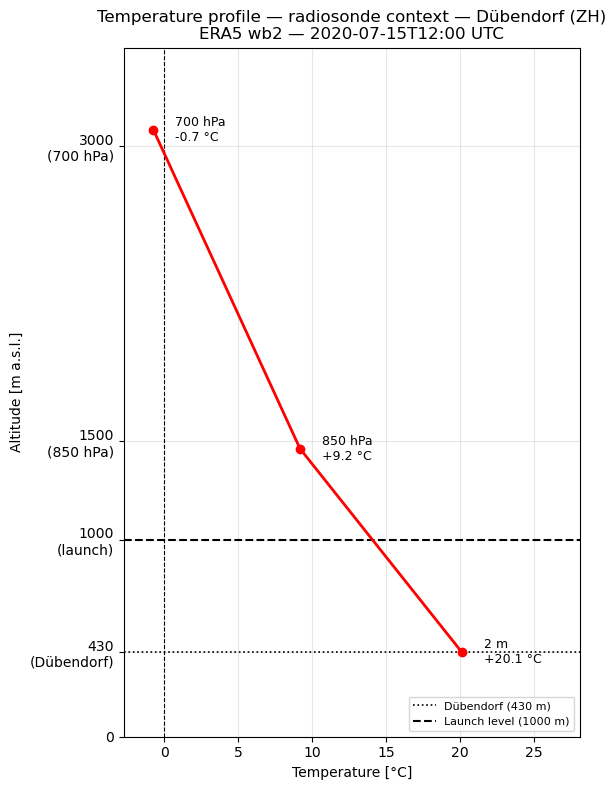

In [ ]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. Load ERA5 from weatherbench2
# ============================================================
era5_path = 'gs://weatherbench2/datasets/era5/1959-2023_01_10-wb13-6h-1440x721_with_derived_variables.zarr'
xera5 = xr.open_zarr(era5_path, consolidated=True, decode_timedelta=True)

lat_dub = 47.40
lon_dub = 8.62
date_sel = '2020-07-15T12:00:00'

sel_kwargs = dict(latitude=lat_dub, longitude=lon_dub,
                  time=date_sel, method='nearest')

# ============================================================
# 2. Extract relevant levels
# ============================================================
t2m   = xera5['2m_temperature'].sel(**sel_kwargs).load()
tprof = xera5['temperature'].sel(**sel_kwargs).load()

# Only levels above Zurich (~400 m) and launch (~1000 m)
# 850 hPa ≈ 1500 m, 700 hPa ≈ 3000 m
useful_levels = [850, 700]
t_useful = tprof.sel(level=useful_levels) - 273.15
t2m_C    = float(t2m - 273.15)

# ============================================================
# 3. Table with approximate real altitude
# ============================================================
# Simplified hypsometric equation with mean T ≈ 285 K, p0 = 1013 hPa
def p_to_z_asl(p, T_mean=285, p0=1013):
    R, g = 287.05, 9.81
    return (R * T_mean / g) * np.log(p0 / p)

pressures = [None, 850, 700]
z_asl     = [430, p_to_z_asl(850), p_to_z_asl(700)]  # m a.s.l.
temps_C   = [t2m_C,
             float(t_useful.sel(level=850)),
             float(t_useful.sel(level=700))]
labels    = ['2 m (Dübendorf ~430 m asl)',
             '850 hPa (~1500 m asl)',
             '700 hPa (~3000 m asl)']

print(f"Grid point: lat={float(tprof.latitude):.3f}, "
      f"lon={float(tprof.longitude):.3f}")
print(f"Date: {tprof.time.values}\n")
print(f"{'Level':<28} {'z≈ [m asl]':>12} {'T [°C]':>10}")
print("-" * 52)
for lab, z, T in zip(labels, z_asl, temps_C):
    print(f"{lab:<28} {z:>12.0f} {T:>+10.2f}")

# Temperature lapse rate between launch and 850 hPa
dT = temps_C[1] - temps_C[0]
dz = (z_asl[1] - 1000) / 1000   # km
lapse = -dT / dz
print(f"\nTemperature lapse rate between launch (1000 m) and 850 hPa: {lapse:.1f} °C/km")
print(f"  (standard atmosphere = 6.5 °C/km, SALR ≈ 5.0, DALR ≈ 9.8)")

# ============================================================
# 4. Plot (black & white)
# ============================================================
fig, ax = plt.subplots(figsize=(6, 8))

# Main line
ax.plot(temps_C, z_asl, marker='o', linewidth=2,
        color='red', markersize=6, zorder=5)

# Reference altitude lines
ax.axhline(430, linestyle=':', linewidth=1.2,
           color='black', label='Dübendorf (430 m)')
ax.axhline(1000, linestyle='--', linewidth=1.5,
           color='black', label='Launch level (1000 m)')

# Labels next to points
for T, z, lab in zip(temps_C, z_asl, labels):
    ax.annotate(f'  {lab.split("(")[0].strip()}\n  {T:+.1f} °C',
                xy=(T, z), xytext=(10, 0),
                textcoords='offset points',
                va='center', fontsize=9)

# Zero temperature line
ax.axvline(0, color='black', linestyle='--', linewidth=0.8)

ax.set_xlabel('Temperature [°C]')
ax.set_ylabel('Altitude [m a.s.l.]')
ax.set_ylim(0, 3500)
ax.set_yticks([0, 430, 1000, 1500, 3000])
ax.set_yticklabels(['0', '430\n(Dübendorf)', '1000\n(launch)', '1500\n(850 hPa)', '3000\n(700 hPa)'])

# X-axis margin
xmin = min(temps_C) - 2
xmax = max(temps_C) + 8
ax.set_xlim(xmin, xmax)

ax.set_title(f'Temperature profile — radiosonde context — Dübendorf (ZH)\n'
             f'ERA5 wb2 — {str(tprof.time.values)[:16]} UTC')

ax.legend(loc='lower right', fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Grid point: lat=47.500, lon=8.500
Date: 2020-07-15T12:00:00.000000000

Level                          z≈[m]   |V|[m/s]   dir[°]   u[m/s]   v[m/s]
------------------------------------------------------------------------
10 m (Dübendorf ~430 m asl)      430       2.92      285    +2.82    -0.74
850 hPa (~1500 m asl)           1463       6.04      261    +5.97    +0.91
700 hPa (~3000 m asl)           3082      14.72      244   +13.27    +6.36

Wind shear |V| between 10 m and 850 hPa: +3.0 (m/s)/km


/tmp/ipykernel_30410/2787267029.py:114: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['0', '430\n(Dübendorf)', '1000\n(launch)',


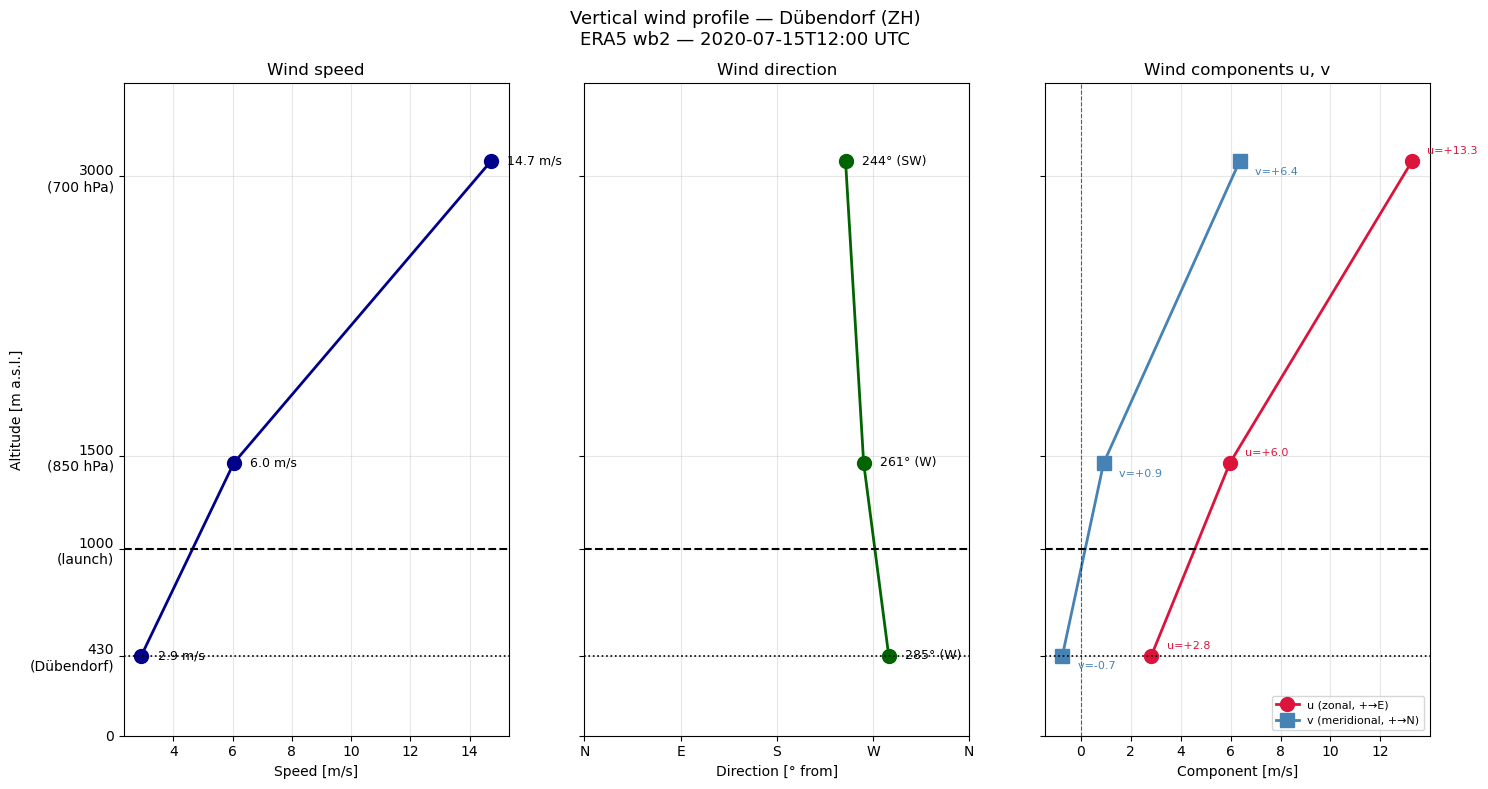

In [ ]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. Load ERA5 from weatherbench2
# ============================================================
era5_path = 'gs://weatherbench2/datasets/era5/1959-2023_01_10-wb13-6h-1440x721_with_derived_variables.zarr'
xera5 = xr.open_zarr(era5_path, consolidated=True, decode_timedelta=True)

lat_dub = 47.40
lon_dub = 8.62
date_sel = '2020-07-15T12:00:00'

sel_kwargs = dict(latitude=lat_dub, longitude=lon_dub,
                  time=date_sel, method='nearest')

# ============================================================
# 2. Extract 10 m wind + useful levels (850, 700 hPa)
# ============================================================
u10 = xera5['10m_u_component_of_wind'].sel(**sel_kwargs).load()
v10 = xera5['10m_v_component_of_wind'].sel(**sel_kwargs).load()

uprof = xera5['u_component_of_wind'].sel(**sel_kwargs).load()
vprof = xera5['v_component_of_wind'].sel(**sel_kwargs).load()

# Only levels above launch (~1000 m asl)
useful_levels = [850, 700]
u_useful = uprof.sel(level=useful_levels)
v_useful = vprof.sel(level=useful_levels)

# ============================================================
# 3. Compute wind speed and direction
# ============================================================
def wind_speed(u, v):
    return np.sqrt(u**2 + v**2)

def wind_dir(u, v):
    """Meteorological direction: where the wind COMES FROM (0°=N, 90°=E...)"""
    return (270 - np.degrees(np.arctan2(v, u))) % 360

# 10 m (surface)
wspd_10m = float(wind_speed(u10, v10))
wdir_10m = float(wind_dir(u10, v10))

# 850 and 700 hPa
wspd_levels = [wind_speed(float(u_useful.sel(level=l)),
                          float(v_useful.sel(level=l)))
               for l in useful_levels]
wdir_levels = [wind_dir(float(u_useful.sel(level=l)),
                        float(v_useful.sel(level=l)))
               for l in useful_levels]
u_levels = [float(u_useful.sel(level=l)) for l in useful_levels]
v_levels = [float(v_useful.sel(level=l)) for l in useful_levels]

# ============================================================
# 4. Approximate altitude
# ============================================================
def p_to_z_asl(p, T_mean=285, p0=1013):
    R, g = 287.05, 9.81
    return (R * T_mean / g) * np.log(p0 / p)

z_asl    = [430, p_to_z_asl(850), p_to_z_asl(700)]
wspd_all = [wspd_10m] + wspd_levels
wdir_all = [wdir_10m] + wdir_levels
u_all    = [float(u10)] + u_levels
v_all    = [float(v10)] + v_levels
labels   = ['10 m (Dübendorf ~430 m asl)',
            '850 hPa (~1500 m asl)',
            '700 hPa (~3000 m asl)']

# ============================================================
# 5. Print table
# ============================================================
print(f"Grid point: lat={float(uprof.latitude):.3f}, "
      f"lon={float(uprof.longitude):.3f}")
print(f"Date: {uprof.time.values}\n")
print(f"{'Level':<28} {'z≈[m]':>7} {'|V|[m/s]':>10} "
      f"{'dir[°]':>8} {'u[m/s]':>8} {'v[m/s]':>8}")
print("-" * 72)
for lab, z, ws, wd, u, v in zip(labels, z_asl, wspd_all,
                                wdir_all, u_all, v_all):
    print(f"{lab:<28} {z:>7.0f} {ws:>10.2f} {wd:>8.0f} "
          f"{u:>+8.2f} {v:>+8.2f}")

# Wind shear between 10 m and 850 hPa
dv = wspd_all[1] - wspd_all[0]
dz = (z_asl[1] - 430) / 1000   # km
print(f"\nWind shear |V| between 10 m and 850 hPa: {dv/dz:+.1f} (m/s)/km")

# ============================================================
# 6. Plot: |V|, direction, and components u & v
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 8), sharey=True)

def add_context(ax):
    """Reference lines only (no background shading)"""
    ax.axhline(430,  color='black', linestyle=':',  linewidth=1.2)
    ax.axhline(1000, color='black', linestyle='--', linewidth=1.5)
    ax.set_ylim(0, 3500)
    ax.set_yticks([0, 430, 1000, 1500, 3000])
    ax.grid(True, alpha=0.3)

# --- Panel 1: wind speed ---
ax = axes[0]
ax.plot(wspd_all, z_asl, marker='o', color='darkblue',
        linewidth=2, markersize=10)
for ws, z in zip(wspd_all, z_asl):
    ax.annotate(f'  {ws:.1f} m/s',
                xy=(ws, z), xytext=(6, 0),
                textcoords='offset points', va='center', fontsize=9)
ax.set_xlabel('Speed [m/s]')
ax.set_ylabel('Altitude [m a.s.l.]')
ax.set_yticklabels(['0', '430\n(Dübendorf)', '1000\n(launch)',
                    '1500\n(850 hPa)', '3000\n(700 hPa)'])
ax.set_title('Wind speed')
add_context(ax)

# --- Panel 2: wind direction ---
ax = axes[1]
ax.plot(wdir_all, z_asl, marker='o', color='darkgreen',
        linewidth=2, markersize=10)
for wd, z in zip(wdir_all, z_asl):
    dirs = ['N','NE','E','SE','S','SW','W','NW','N']
    card = dirs[int((wd + 22.5) / 45) % 8]
    ax.annotate(f'  {wd:.0f}° ({card})',
                xy=(wd, z), xytext=(6, 0),
                textcoords='offset points', va='center', fontsize=9)
ax.set_xlabel('Direction [° from]')
ax.set_xlim(0, 360)
ax.set_xticks([0, 90, 180, 270, 360])
ax.set_xticklabels(['N', 'E', 'S', 'W', 'N'])
ax.set_title('Wind direction')
add_context(ax)

# --- Panel 3: u and v components ---
ax = axes[2]
ax.plot(u_all, z_asl, marker='o', color='crimson',
        linewidth=2, markersize=10, label='u (zonal, +→E)')
ax.plot(v_all, z_asl, marker='s', color='steelblue',
        linewidth=2, markersize=10, label='v (meridional, +→N)')
ax.axvline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.6)

for u, v, z in zip(u_all, v_all, z_asl):
    ax.annotate(f'  u={u:+.1f}',
                xy=(u, z), xytext=(6,  5),
                textcoords='offset points', fontsize=8, color='crimson')
    ax.annotate(f'  v={v:+.1f}',
                xy=(v, z), xytext=(6, -10),
                textcoords='offset points', fontsize=8, color='steelblue')

ax.set_xlabel('Component [m/s]')
ax.set_title('Wind components u, v')
ax.legend(loc='lower right', fontsize=8)
add_context(ax)

fig.suptitle(f'Vertical wind profile — Dübendorf (ZH)\n'
             f'ERA5 wb2 — {str(uprof.time.values)[:16]} UTC',
             fontsize=13)

plt.tight_layout()
plt.show()

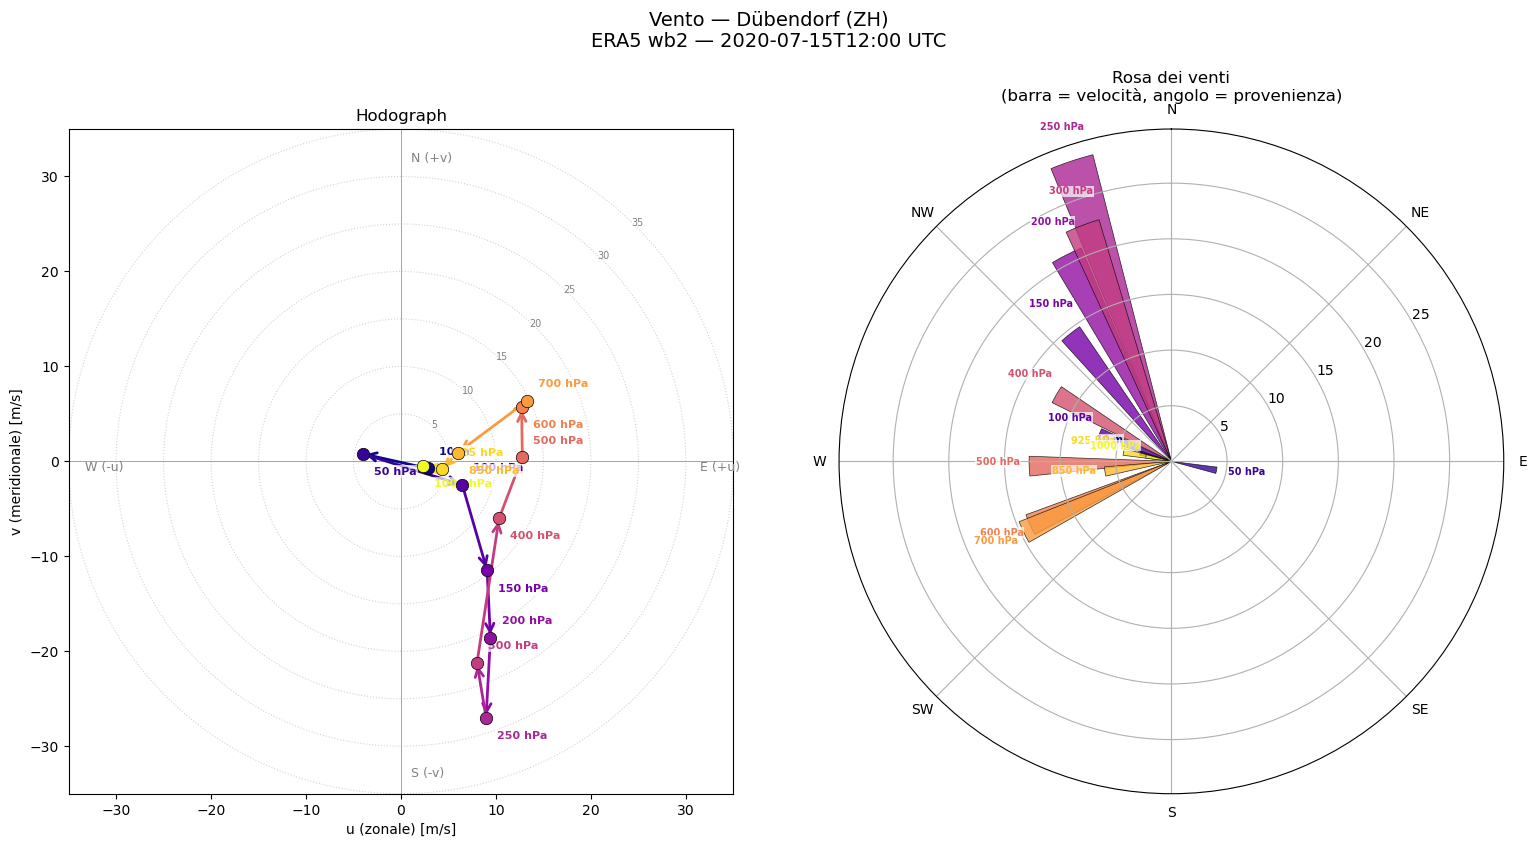


   Livello    z≈[m]   |V|[m/s]   dir[°]   da   u[m/s]   v[m/s]
--------------------------------------------------------------
      10 m      430       2.92      285    W    +2.82    -0.74
    50 hPa    22889       4.13      101    E    -4.05    +0.80
   100 hPa    17616       6.92      291    W    +6.46    -2.49
   150 hPa    14531      14.64      322   NW    +9.07   -11.49
   200 hPa    12343      20.81      333   NW    +9.42   -18.56
   250 hPa    10645      28.44      342    N    +8.96   -26.99
   300 hPa     9258      22.67      339    N    +8.00   -21.21
   400 hPa     7069      11.95      300   NW   +10.33    -6.01
   500 hPa     5372      12.79      268    W   +12.78    +0.43
   600 hPa     3985      13.92      246   SW   +12.70    +5.70
   700 hPa     2812      14.72      244   SW   +13.27    +6.36
   850 hPa     1335       6.04      261    W    +5.97    +0.91
   925 hPa      691       4.38      281    W    +4.30    -0.85
  1000 hPa       98       2.33      281    W    +2.28 

In [ ]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch

# ============================================================
# 1. Carica ERA5 da weatherbench2
# ============================================================
era5_path = 'gs://weatherbench2/datasets/era5/1959-2023_01_10-wb13-6h-1440x721_with_derived_variables.zarr'
xera5 = xr.open_zarr(era5_path, consolidated=True, decode_timedelta=True)

lat_dub = 47.40
lon_dub = 8.62
date_sel = '2020-07-15T12:00:00'

sel_kwargs = dict(latitude=lat_dub, longitude=lon_dub,
                  time=date_sel, method='nearest')

# ============================================================
# 2. Estrai vento: 10 m + tutti i 13 livelli
# ============================================================
u10 = float(xera5['10m_u_component_of_wind'].sel(**sel_kwargs).load())
v10 = float(xera5['10m_v_component_of_wind'].sel(**sel_kwargs).load())

uprof = xera5['u_component_of_wind'].sel(**sel_kwargs).load()
vprof = xera5['v_component_of_wind'].sel(**sel_kwargs).load()

levels = uprof.level.values
u_vals = uprof.values
v_vals = vprof.values

# Prependi il valore a 10 m
all_levels_str = ['10 m'] + [f'{int(l)} hPa' for l in levels]
all_u = np.concatenate([[u10], u_vals])
all_v = np.concatenate([[v10], v_vals])
all_wspd = np.sqrt(all_u**2 + all_v**2)
all_wdir = (270 - np.degrees(np.arctan2(all_v, all_u))) % 360

# Altitudine approssimata
def p_to_z(p, T_mean=260, p0=1013):
    R, g = 287.05, 9.81
    return (R * T_mean / g) * np.log(p0 / p)

all_z = [430] + [p_to_z(p) for p in levels]

# Colori per ogni livello (colormap basata sull'altitudine)
cmap = plt.cm.plasma
norm = plt.Normalize(vmin=0, vmax=len(all_u)-1)
colors = [cmap(norm(i)) for i in range(len(all_u))]

# ============================================================
# 3. HODOGRAPH
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

ax = axes[0]

# Cerchi di riferimento per la velocità
max_wind = np.ceil(np.max(all_wspd) / 5) * 5 + 5
for r in np.arange(5, max_wind + 1, 5):
    circle = plt.Circle((0, 0), r, fill=False, color='lightgray',
                         linestyle=':', linewidth=0.8)
    ax.add_patch(circle)
    ax.annotate(f'{int(r)}', xy=(r * 0.71, r * 0.71),
                fontsize=7, color='gray', ha='center')

# Assi cardinali
ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
ax.annotate('E (+u)', xy=(max_wind * 0.9, -1), fontsize=9, color='gray')
ax.annotate('W (-u)', xy=(-max_wind * 0.95, -1), fontsize=9, color='gray')
ax.annotate('N (+v)', xy=(1, max_wind * 0.9), fontsize=9, color='gray')
ax.annotate('S (-v)', xy=(1, -max_wind * 0.95), fontsize=9, color='gray')

# Disegna l'hodograph: segmenti tra livelli consecutivi
for i in range(len(all_u) - 1):
    ax.annotate('',
                xy=(all_u[i+1], all_v[i+1]),
                xytext=(all_u[i], all_v[i]),
                arrowprops=dict(arrowstyle='->', color=colors[i],
                                linewidth=2, mutation_scale=15))

# Punti e etichette per ogni livello
for i, (u, v, lab) in enumerate(zip(all_u, all_v, all_levels_str)):
    ax.scatter(u, v, color=colors[i], s=80, zorder=5, edgecolors='black',
               linewidth=0.5)
    # Posiziona le etichette con offset per evitare sovrapposizione
    offset = 10 if i % 2 == 0 else -15
    ax.annotate(lab, xy=(u, v), xytext=(8, offset),
                textcoords='offset points', fontsize=8,
                color=colors[i], fontweight='bold',
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none',
                          pad=1))

ax.set_xlim(-max_wind, max_wind)
ax.set_ylim(-max_wind, max_wind)
ax.set_aspect('equal')
ax.set_xlabel('u (zonale) [m/s]')
ax.set_ylabel('v (meridionale) [m/s]')
ax.set_title('Hodograph')

# ============================================================
# 4. ROSA DEI VENTI (per ogni livello)
# ============================================================
ax2 = fig.add_subplot(122, projection='polar')
# Rimuovi il subplot originale
axes[1].remove()

# Nella rosa dei venti polare, 0° = N (top), rotazione oraria
# Converti direzione meteo in angolo polare: theta = 90° - dir meteo (rad)
# oppure: theta_rad = np.radians(90 - wdir)  ma in proiezione polare
# matplotlib: 0° = destra (E). Per avere 0° = N, offset = pi/2
# Direzione meteo = da dove VIENE il vento

theta = np.radians(all_wdir)

# Barre per ogni livello
bar_width = np.radians(8)
bars = ax2.bar(theta, all_wspd, width=bar_width,
               color=colors, edgecolor='black', linewidth=0.5,
               alpha=0.8)

# Etichette livello
for i, (th, ws, lab) in enumerate(zip(theta, all_wspd, all_levels_str)):
    # Etichetta fuori dalla barra
    ax2.annotate(lab, xy=(th, ws), xytext=(th, ws + max_wind * 0.08),
                 textcoords='data', fontsize=7, ha='center', va='bottom',
                 color=colors[i], fontweight='bold',
                 bbox=dict(facecolor='white', alpha=0.7,
                           edgecolor='none', pad=0.5))

# Imposta la rosa: N in alto, senso orario
ax2.set_theta_zero_location('N')
ax2.set_theta_direction(-1)   # senso orario
ax2.set_thetagrids([0, 45, 90, 135, 180, 225, 270, 315],
                   labels=['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'])
ax2.set_rlabel_position(60)
ax2.set_title('Rosa dei venti\n(barra = velocità, angolo = provenienza)',
              pad=20)

fig.suptitle(f'Vento — Dübendorf (ZH)\n'
             f'ERA5 wb2 — {date_sel[:16]} UTC',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# ============================================================
# 5. Tabella riassuntiva
# ============================================================
print(f"\n{'Livello':>10} {'z≈[m]':>8} {'|V|[m/s]':>10} "
      f"{'dir[°]':>8} {'da':>4} {'u[m/s]':>8} {'v[m/s]':>8}")
print("-" * 62)
dirs_names = ['N','NE','E','SE','S','SW','W','NW','N']
for lab, z, ws, wd, u, v in zip(all_levels_str, all_z,
                                 all_wspd, all_wdir, all_u, all_v):
    card = dirs_names[int((wd + 22.5) / 45) % 8]
    print(f"{lab:>10} {z:>8.0f} {ws:>10.2f} {wd:>8.0f} {card:>4} "
          f"{u:>+8.2f} {v:>+8.2f}")

# Veering o backing?
delta_dir = all_wdir[-1] - all_wdir[0]
if delta_dir > 0:
    print(f"\n→ VEERING (rotazione oraria con la quota, Δdir = +{delta_dir:.0f}°)")
    print("  → Tipico: avvezione calda (aria calda dal sud/ovest)")
else:
    print(f"\n→ BACKING (rotazione antioraria con la quota, Δdir = {delta_dir:.0f}°)")
    print("  → Tipico: avvezione fredda (aria fredda dal nord)")